<a href="https://colab.research.google.com/github/adigenova/uohdm/blob/main/code/taller_testing_estadistico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Testing estadístico práctico en **R**

Taller de inferencia estadistica en R

## Qué aprenderás

- cómo explorar datos con `iris`
- cómo elegir un test estadístico
- hipótesis nula y alternativa
- test t, ANOVA, chi-cuadrado, Fisher
- alternativas no paramétricas
- correlación y regresión lineal
- gráficos en R
- ejercicios prácticos

In [1]:
# Instalación de paquetes en R
packages <- c("tidyverse", "rstatix", "ggpubr", "broom", "effectsize")
to_install <- packages[!packages %in% installed.packages()[, "Package"]]
if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘corrplot’, ‘car’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘bayestestR’, ‘insight’, ‘parameters’, ‘performance’, ‘datawizard’




In [2]:
library(tidyverse)
library(rstatix)
library(ggpubr)
library(broom)
library(effectsize)

data(iris)

glimpse(iris)
head(iris)
summary(iris)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘effectsize’


The following objects are masked from ‘package:rstatix’:

    cohens_d, eta_squared




Rows: 150
Columns: 5
$ Sepal.Length <dbl> 5.1, 4.9, 4.7, 4.6, 5.0, 5.4, 4.6, 5.0, 4.4, 4.9, 5.4, 4.…
$ Sepal.Width  <dbl> 3.5, 3.0, 3.2, 3.1, 3.6, 3.9, 3.4, 3.4, 2.9, 3.1, 3.7, 3.…
$ Petal.Length <dbl> 1.4, 1.4, 1.3, 1.5, 1.4, 1.7, 1.4, 1.5, 1.4, 1.5, 1.5, 1.…
$ Petal.Width  <dbl> 0.2, 0.2, 0.2, 0.2, 0.2, 0.4, 0.3, 0.2, 0.2, 0.1, 0.2, 0.…
$ Species      <fct> setosa, setosa, setosa, setosa, setosa, setosa, setosa, s…


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
                

## 1. Exploración inicial

Antes de elegir un test, revisa:

- tipo de variables
- número de grupos
- distribución de los datos
- presencia de outliers
- si quieres comparar grupos o relacionar variables

In [3]:
iris %>% count(Species)

Species,n
<fct>,<int>
setosa,50
versicolor,50
virginica,50


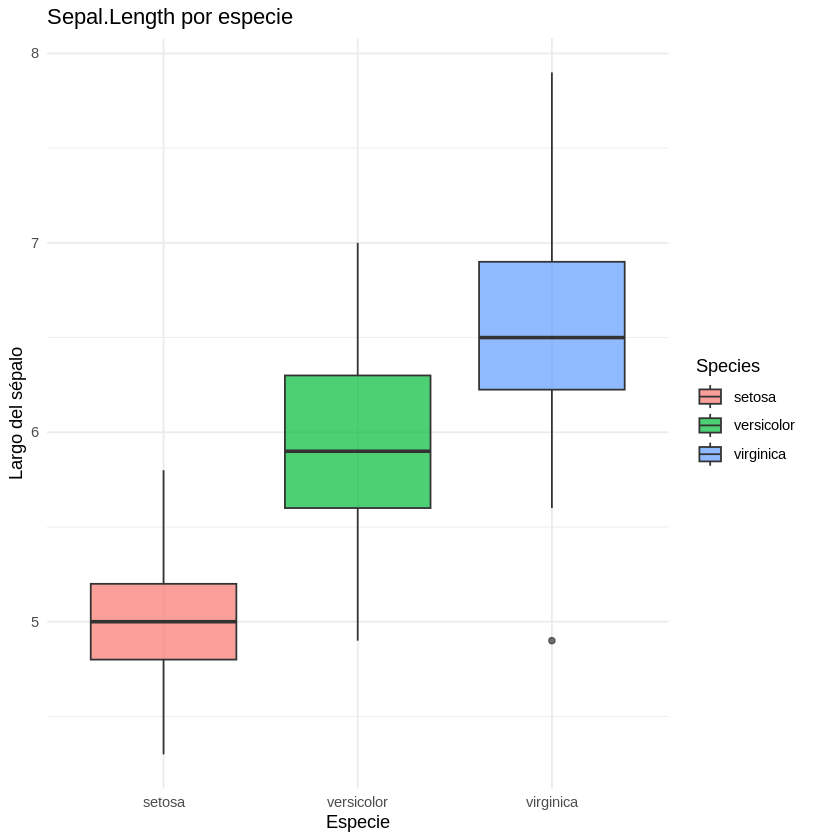

In [4]:
ggplot(iris, aes(x = Species, y = Sepal.Length, fill = Species)) +
  geom_boxplot(alpha = 0.7) +
  theme_minimal() +
  labs(title = "Sepal.Length por especie", x = "Especie", y = "Largo del sépalo")

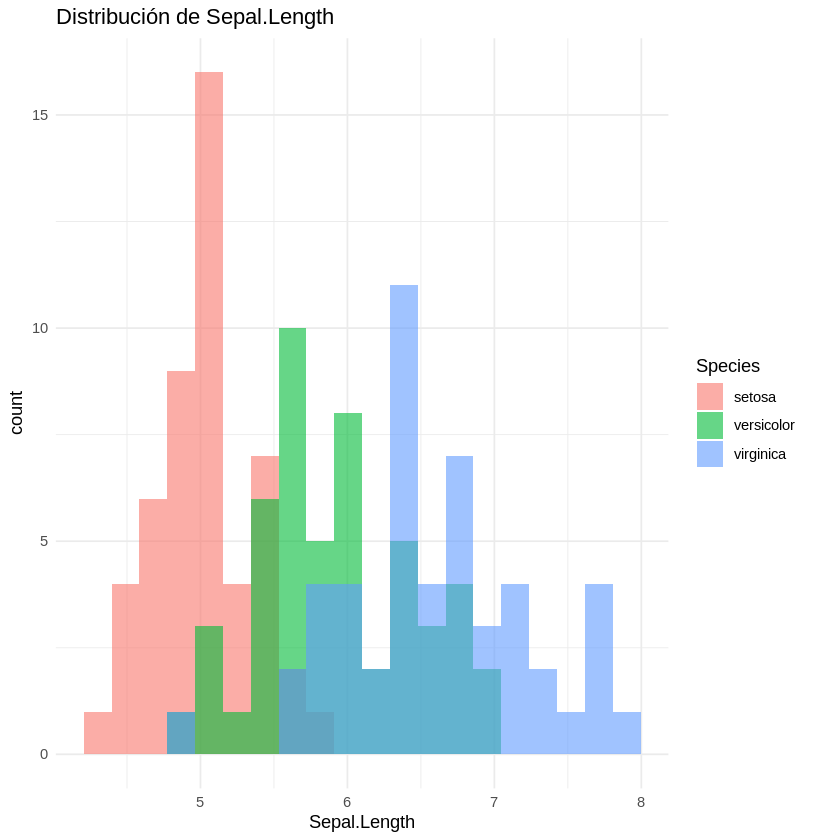

In [5]:
ggplot(iris, aes(x = Sepal.Length, fill = Species)) +
  geom_histogram(bins = 20, alpha = 0.6, position = "identity") +
  theme_minimal() +
  labs(title = "Distribución de Sepal.Length")

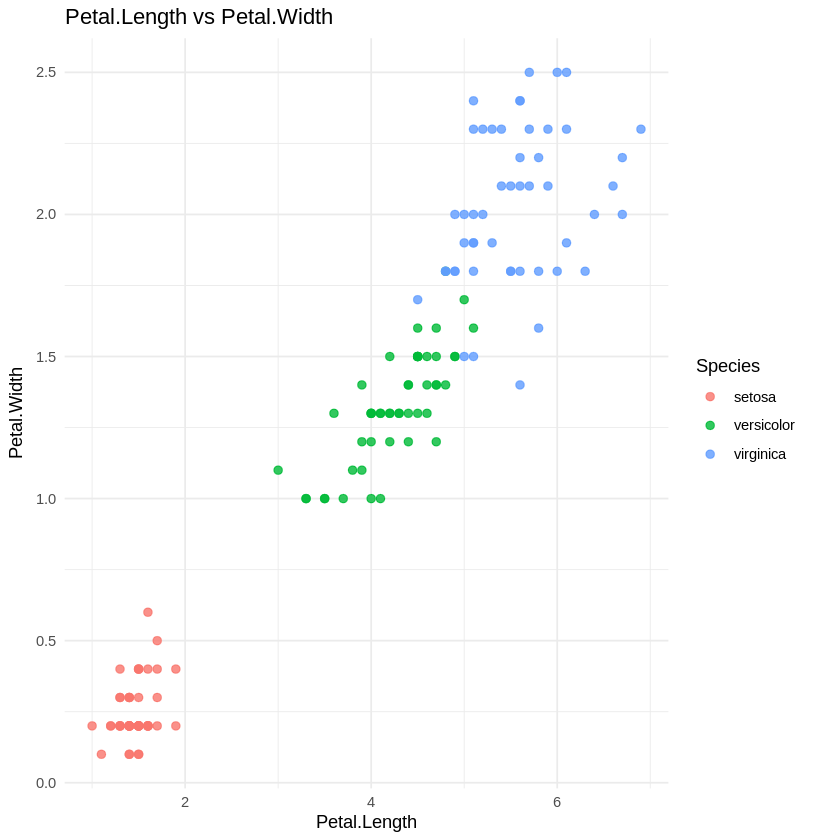

In [6]:
ggplot(iris, aes(x = Petal.Length, y = Petal.Width, color = Species)) +
  geom_point(size = 2, alpha = 0.8) +
  theme_minimal() +
  labs(title = "Petal.Length vs Petal.Width")

### Ejercicio 1

1. ¿Qué variable parece separar mejor a las especies?
2. ¿Dónde observas más solapamiento?
3. ¿Qué gráfico usarías para comparar `Sepal.Width` entre especies?

## 2. Regla práctica para elegir un test

- **1 media vs un valor** → test t de una muestra  
- **2 grupos independientes** → test t de dos muestras / Welch  
- **3 o más grupos** → ANOVA  
- **alternativa no paramétrica** → Wilcoxon / Mann-Whitney / Kruskal-Wallis  
- **dos variables categóricas** → chi-cuadrado o Fisher  
- **dos variables numéricas** → correlación o regresión

## 3. Supuestos

### Normalidad
- **H0**: los datos siguen una distribución normal

### Homogeneidad de varianzas
- **H0**: las varianzas son iguales entre grupos

In [7]:
iris %>%
  group_by(Species) %>%
  shapiro_test(Sepal.Length)

Species,variable,statistic,p
<fct>,<chr>,<dbl>,<dbl>
setosa,Sepal.Length,0.9776985,0.4595132
versicolor,Sepal.Length,0.9778357,0.4647370
virginica,Sepal.Length,0.9711794,0.2583147


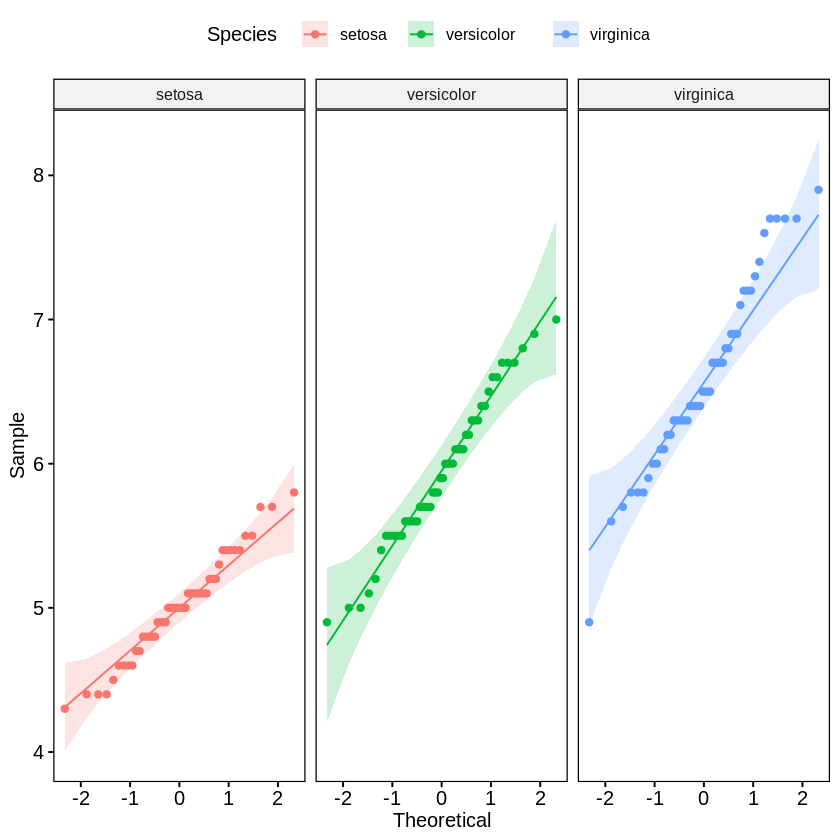

In [8]:
ggqqplot(iris, x = "Sepal.Length", facet.by = "Species", color = "Species")

In [9]:
levene_test(iris, Sepal.Length ~ Species)

df1,df2,statistic,p
<int>,<int>,<dbl>,<dbl>
2,147,6.35272,0.002258528


## 4. Test t de una muestra

### Pregunta
¿La media de `Sepal.Length` es igual a 5.8?

### Hipótesis
- **H0**: media = 5.8
- **H1**: media ≠ 5.8

In [14]:
t.test(iris$Sepal.Length, mu = 5.84)

iris %>%
  summarise(
    media = mean(Sepal.Length),
    sd = sd(Sepal.Length),
    n = n()
  )


	One Sample t-test

data:  iris$Sepal.Length
t = 0.049301, df = 149, p-value = 0.9607
alternative hypothesis: true mean is not equal to 5.84
95 percent confidence interval:
 5.709732 5.976934
sample estimates:
mean of x 
 5.843333 


media,sd,n
<dbl>,<dbl>,<int>
5.843333,0.8280661,150


### Ejercicio 2

Prueba con:

- `mu = 5`
- `mu = 6`
- `mu = 5.84`

¿En cuáles casos rechazas H0?

## 5. Test t de dos muestras independientes

### Pregunta
¿`Sepal.Length` difiere entre `setosa` y `versicolor`?

### Hipótesis
- **H0**: las medias son iguales
- **H1**: las medias son distintas

In [15]:
iris_2 <- iris %>%
  filter(Species %in% c("setosa", "versicolor"))

iris_2 %>%
  group_by(Species) %>%
  summarise(
    media = mean(Sepal.Length),
    sd = sd(Sepal.Length),
    n = n()
  )

Species,media,sd,n
<fct>,<dbl>,<dbl>,<int>
setosa,5.006,0.3524897,50
versicolor,5.936,0.5161711,50


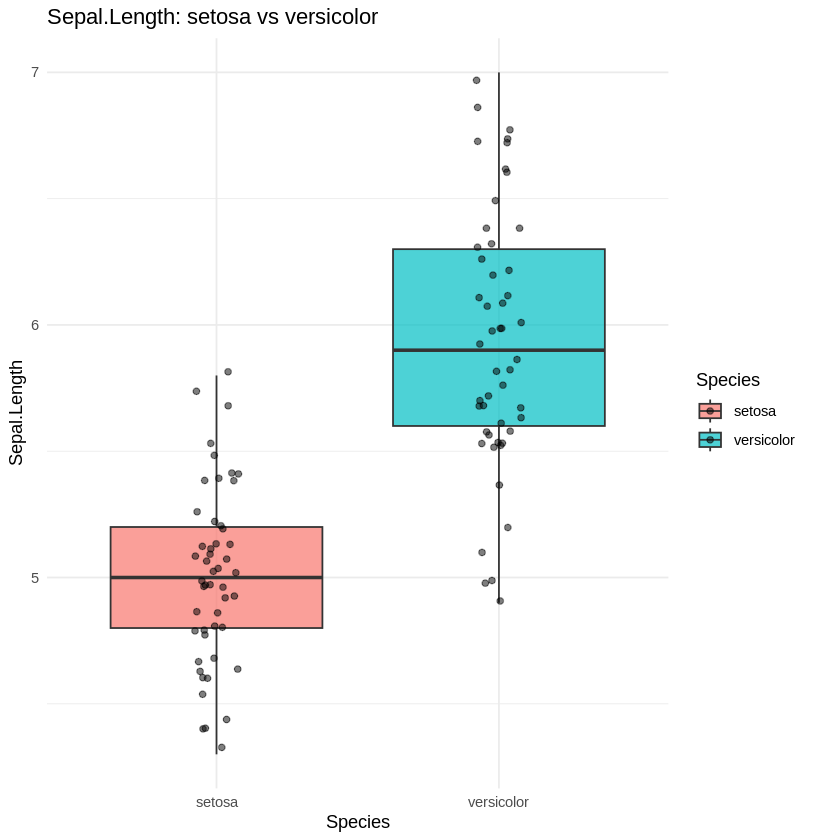

In [16]:
ggplot(iris_2, aes(x = Species, y = Sepal.Length, fill = Species)) +
  geom_boxplot(alpha = 0.7) +
  geom_jitter(width = 0.08, alpha = 0.5) +
  theme_minimal() +
  labs(title = "Sepal.Length: setosa vs versicolor")

In [17]:
t.test(Sepal.Length ~ Species, data = iris_2, var.equal = TRUE)
t.test(Sepal.Length ~ Species, data = iris_2, var.equal = FALSE)
cohens_d(Sepal.Length ~ Species, data = iris_2)


	Two Sample t-test

data:  Sepal.Length by Species
t = -10.521, df = 98, p-value < 2.2e-16
alternative hypothesis: true difference in means between group setosa and group versicolor is not equal to 0
95 percent confidence interval:
 -1.1054165 -0.7545835
sample estimates:
    mean in group setosa mean in group versicolor 
                   5.006                    5.936 



	Welch Two Sample t-test

data:  Sepal.Length by Species
t = -10.521, df = 86.538, p-value < 2.2e-16
alternative hypothesis: true difference in means between group setosa and group versicolor is not equal to 0
95 percent confidence interval:
 -1.1057074 -0.7542926
sample estimates:
    mean in group setosa mean in group versicolor 
                   5.006                    5.936 


Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-2.104197,0.95,-2.590787,-1.61057


# Significancia estadística

Tanto el test t clásico como el de Welch dan:

t = -10.521
p-value < 2.2e-16

Eso significa que la evidencia contra la hipótesis nula es extremadamente fuerte.
Por lo tanto, rechazamos H0 y concluimos que las medias no son iguales.

## Intervalo de confianza

El IC 95% para la diferencia (setosa - versicolor) es aproximadamente:

entre -1.11 y -0.75

Como todo el intervalo es negativo, esto confirma que setosa tiene menor media que versicolor.

## Interpretación
Se observó una diferencia significativa en Sepal.Length entre setosa y versicolor (test t, p < 2.2e-16). La media fue menor en setosa (5.006) que en versicolor (5.936), con una diferencia promedio de aproximadamente 0.93 unidades. El tamaño de efecto fue muy grande (Cohen’s d = -2.10).


## Note on cohen'd
Cohen's d = 0.20, 0.50, and 0.80 se interpretan como tamaños de efectos pequeños, medios, o grandes, respectivamente.

### Ejercicio 3

Repite el análisis para:

- `Sepal.Width`
- `Petal.Length`
- `versicolor` vs `virginica`

## 6. ANOVA

### Pregunta
¿La media de `Sepal.Length` cambia entre las tres especies?

### Hipótesis
- **H0**: todas las medias son iguales
- **H1**: al menos una media difiere

In [ ]:
anova_model <- aov(Sepal.Length ~ Species, data = iris)
summary(anova_model)
model.tables(anova_model, type = "means")
TukeyHSD(anova_model)
eta_squared(anova_model)

In [ ]:
ggplot(iris, aes(x = Species, y = Sepal.Length, fill = Species)) +
  geom_boxplot(alpha = 0.7) +
  theme_minimal() +
  labs(title = "ANOVA visual: Sepal.Length por especie")

### Ejercicio 4

Aplica ANOVA a:

- `Sepal.Width ~ Species`
- `Petal.Length ~ Species`
- `Petal.Width ~ Species`

Luego compara tamaños de efecto.

## 7. Alternativas no paramétricas

### Kruskal-Wallis
- **H0**: las distribuciones/medianas son equivalentes entre grupos
- **H1**: al menos un grupo difiere

In [ ]:
kruskal.test(Sepal.Length ~ Species, data = iris)
kruskal_effsize(iris, Sepal.Length ~ Species)

### Wilcoxon / Mann-Whitney
- **H0**: las distribuciones de dos grupos son equivalentes
- **H1**: difieren

In [ ]:
wilcox.test(Sepal.Length ~ Species, data = iris_2)
wilcox_effsize(iris_2, Sepal.Length ~ Species)

### Ejercicio 5

Compara para `Sepal.Width`:

- test t vs Wilcoxon
- ANOVA vs Kruskal-Wallis

¿Cambian las conclusiones?

## 8. Asociación entre variables categóricas: chi-cuadrado y Fisher

Construiremos una variable categórica artificial:

- `Sepal_cat = "Corta"` si `Sepal.Length` < mediana
- `Sepal_cat = "Larga"` si `Sepal.Length` >= mediana

In [18]:
iris_cat <- iris %>%
  mutate(Sepal_cat = if_else(Sepal.Length < median(Sepal.Length), "Corta", "Larga"))

tabla <- table(iris_cat$Species, iris_cat$Sepal_cat)
tabla
prop.table(tabla, margin = 1)

            
             Corta Larga
  setosa        49     1
  versicolor    21    29
  virginica      3    47

            
             Corta Larga
  setosa      0.98  0.02
  versicolor  0.42  0.58
  virginica   0.06  0.94

In [19]:
chisq.test(tabla)
fisher.test(tabla)


	Pearson's Chi-squared test

data:  tabla
X-squared = 86.035, df = 2, p-value < 2.2e-16



	Fisher's Exact Test for Count Data

data:  tabla
p-value < 2.2e-16
alternative hypothesis: two.sided


### Hipótesis
- **H0**: no hay asociación entre las variables categóricas
- **H1**: sí hay asociación

### Ejercicio 6

Crea una variable categórica usando `Petal.Width` y evalúa su asociación con `Species`.

## 9. Correlación

### Pregunta
¿Existe asociación entre `Petal.Length` y `Petal.Width`?

### Hipótesis
- **H0**: correlación = 0
- **H1**: correlación ≠ 0

`geom_smooth()` using formula = 'y ~ x'


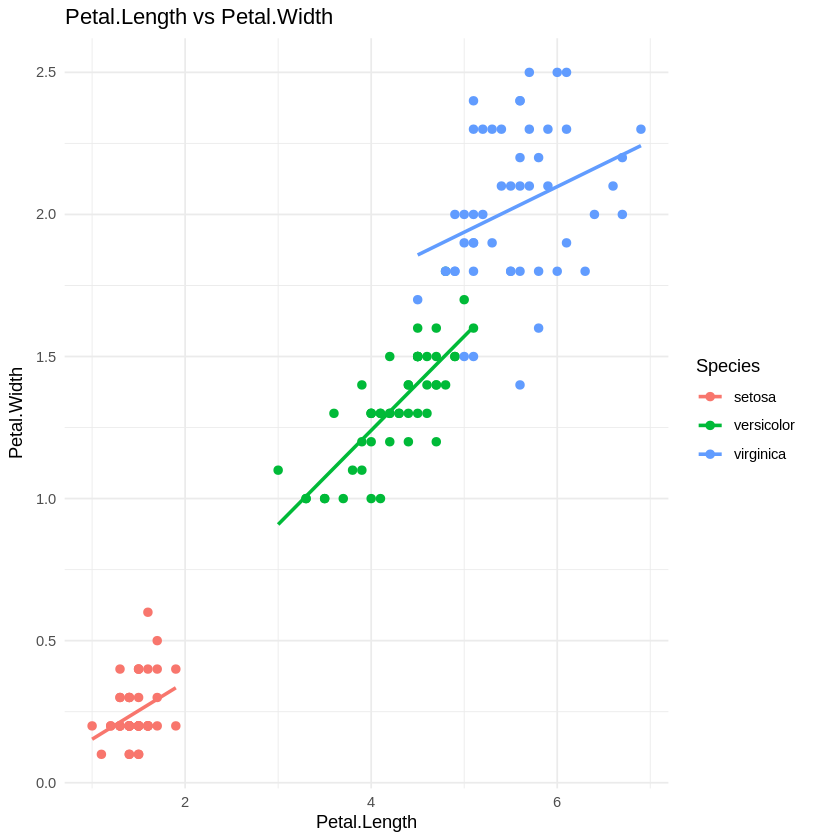

In [20]:
ggplot(iris, aes(x = Petal.Length, y = Petal.Width, color = Species)) +
  geom_point(size = 2) +
  geom_smooth(method = "lm", se = FALSE) +
  theme_minimal() +
  labs(title = "Petal.Length vs Petal.Width")

In [21]:
cor.test(iris$Petal.Length, iris$Petal.Width, method = "pearson")
cor.test(iris$Petal.Length, iris$Petal.Width, method = "spearman")
cor.test(iris$Petal.Length, iris$Petal.Width, method = "kendall")


	Pearson's product-moment correlation

data:  iris$Petal.Length and iris$Petal.Width
t = 43.387, df = 148, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9490525 0.9729853
sample estimates:
      cor 
0.9628654 


Warning message in cor.test.default(iris$Petal.Length, iris$Petal.Width, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  iris$Petal.Length and iris$Petal.Width
S = 35061, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.9376668 



	Kendall's rank correlation tau

data:  iris$Petal.Length and iris$Petal.Width
z = 13.968, p-value < 2.2e-16
alternative hypothesis: true tau is not equal to 0
sample estimates:
      tau 
0.8068907 


### Ejercicio 7

Calcula correlaciones entre:

- `Sepal.Length` y `Sepal.Width`
- `Sepal.Length` y `Petal.Length`
- `Sepal.Width` y `Petal.Width`

## 10. Regresión lineal simple

### Modelo
\[
Petal.Width = \beta_0 + \beta_1 Petal.Length + \varepsilon
\]

### Hipótesis sobre la pendiente
- **H0**: \(\beta_1 = 0\)
- **H1**: \(\beta_1 \neq 0\)

In [22]:
lm1 <- lm(Petal.Width ~ Petal.Length, data = iris)
summary(lm1)
tidy(lm1)
glance(lm1)


Call:
lm(formula = Petal.Width ~ Petal.Length, data = iris)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.56515 -0.12358 -0.01898  0.13288  0.64272 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -0.363076   0.039762  -9.131  4.7e-16 ***
Petal.Length  0.415755   0.009582  43.387  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2065 on 148 degrees of freedom
Multiple R-squared:  0.9271,	Adjusted R-squared:  0.9266 
F-statistic:  1882 on 1 and 148 DF,  p-value: < 2.2e-16


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.3630755,0.039761990,-9.131221,4.699798e-16
Petal.Length,0.4157554,0.009582436,43.387237,4.675004e-86


r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.9271098,0.9266173,0.2064843,1882.452,4.675004e-86,1,24.79555,-43.59109,-34.55919,6.310096,148,150


`geom_smooth()` using formula = 'y ~ x'


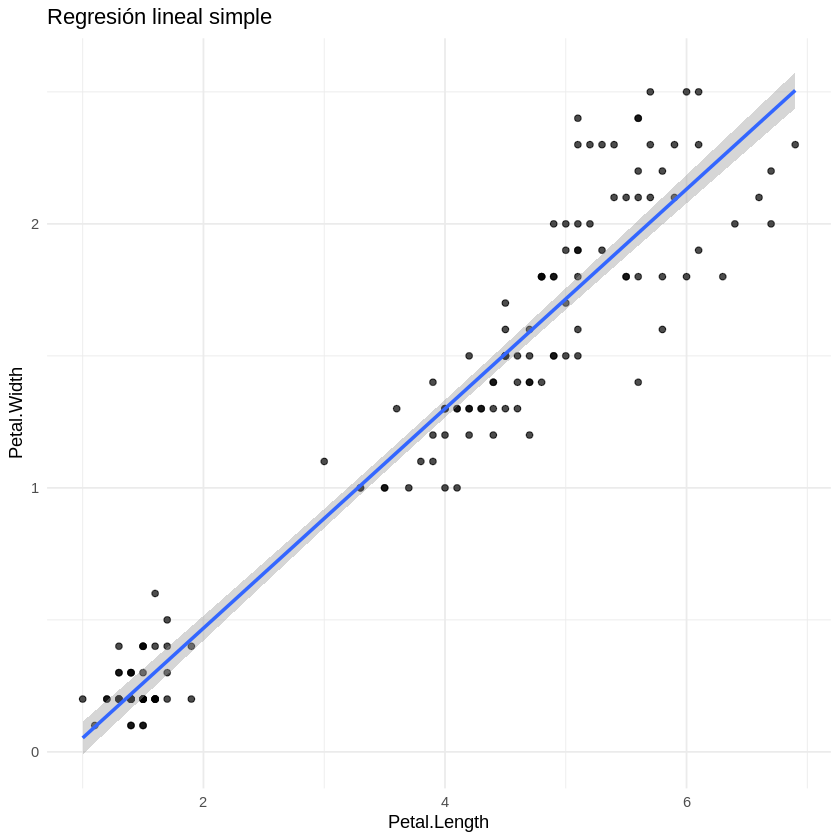

In [23]:
ggplot(iris, aes(x = Petal.Length, y = Petal.Width)) +
  geom_point(alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE) +
  theme_minimal() +
  labs(title = "Regresión lineal simple")

### Ejercicio 8

Ajusta y compara:

- `Sepal.Length ~ Petal.Length`
- `Sepal.Width ~ Petal.Width`

¿Cuál tiene mayor `R²`?

## 11. Ejercicios

Responde con código y una breve interpretación:

1. ¿Qué test usarías para evaluar si `Petal.Length` cambia entre especies?
2. ¿Qué test usarías para comparar `Sepal.Width` entre `setosa` y `virginica`?
3. Construye una variable categórica binaria usando `Petal.Length` y evalúa su asociación con `Species`.
4. ¿Qué variable predice mejor `Petal.Width`?
5. ¿Qué resultados cambiarían si usas tests no paramétricos?

## 12. Desafío final

Completa esta función para recomendar un test.

In [ ]:
elegir_test <- function(y, x, data) {
  y_data <- data[[y]]
  x_data <- data[[x]]

  if (is.numeric(y_data) && is.numeric(x_data)) {
    return("Correlación o regresión lineal")
  }

  if (is.numeric(y_data) && !is.numeric(x_data)) {
    n_grupos <- nlevels(as.factor(x_data))
    if (n_grupos == 2) return("Test t o Wilcoxon/Mann-Whitney")
    if (n_grupos > 2) return("ANOVA o Kruskal-Wallis")
  }

  if (!is.numeric(y_data) && !is.numeric(x_data)) {
    return("Chi-cuadrado o Fisher")
  }

  return("Revisar estructura del problema")
}

elegir_test("Sepal.Length", "Species", iris)
elegir_test("Petal.Length", "Petal.Width", iris)

## 13. Cierre

La clave no es memorizar tests, sino responder bien:

- ¿qué quiero comparar?
- ¿qué tipo de variables tengo?
- ¿cuántos grupos hay?
- ¿se cumplen los supuestos?
- ¿cómo interpreto el resultado en contexto?